In [ ]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(tidyr)
library(ggsci)
library(patchwork)
library(scales)

root <- "/home/data/tanglei01/project/Prostate_atlas"
dir.create(file.path(root, "output/11"), recursive = TRUE, showWarnings = FALSE)

h3_map <- c(
  "CLDN10+SERPINA3+ barrier-defense club cell" = "Barrier-defense club cell",
  "MUC4+AGR3+ secretory club cell" = "Secretory club cell",
  "TGFB2+PLAU+ microenvironment-remodeling club cell" = "Microenvironment-remodeling club cell",
  "IL1A+CCL20+ microenvironment-remodeling hillock cell" = "Microenvironment-remodeling hillock cell",
  "IL1A-OLFM4+ classical homeostatic hillock cell" = "Classical homeostatic hillock cell",
  "MMP7+PIGR+ club-like transitional luminal cell" = "Transitional club cell",
  "KRT13+C19orf33+ hillock-like transitional basal cell" = "Transitional hillock cell"
)
h3_lv <- unname(h3_map)
cols_h3 <- setNames(substr(pal_d3("category20")(7), 1, 7), h3_lv)

type_lv <- c("Normal", "Normal_DB", "Naive_BPH", "5aTreat_BPH", "Per_PC_DB",
             "Naive_PC", "Cribriform_PC", "CRPC_A", "NEPC")
type_lab <- c(Normal = "Normal", Normal_DB = "Normal DB", Naive_BPH = "BPH",
              `5aTreat_BPH` = "5aTreat BPH", Per_PC_DB = "Peri DB",
              Naive_PC = "Naive PC", Cribriform_PC = "Cribriform",
              CRPC_A = "CRPC", NEPC = "NEPC")
gse_club <- c("GSE166782", "GSE179615", "GSE181294")
drop_gse <- "GSE241556"
drop_gse_cells <- function(obj) {
  obj[, as.character(obj[["GSE.ID"]][, 1]) != drop_gse]
}

th <- theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", size = 13),
        legend.title = element_blank())

In [3]:
seu0 <- qs::qread(file.path(root, "output/04/QC_fin.qs"))
epi  <- seu0[, seu0$celltype_manual_H1 == "Epithelial cell"]
seu  <- seu0[, seu0$celltype_manual_H3 %in% names(h3_map)]
rm(seu0); gc()

epi <- drop_gse_cells(epi)
seu <- drop_gse_cells(seu)

seu$h3 <- factor(unname(h3_map[as.character(seu$celltype_manual_H3)]), levels = h3_lv)
Idents(seu) <- seu$h3
qs::qsave(seu, file.path(root, "output/11/club_hillock.qs"))

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3436960,183.6,7133031,381.0,7133031,381.0
Vcells,1911160261,14581.0,8676575928,66197.1,7945896006,60622.4


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


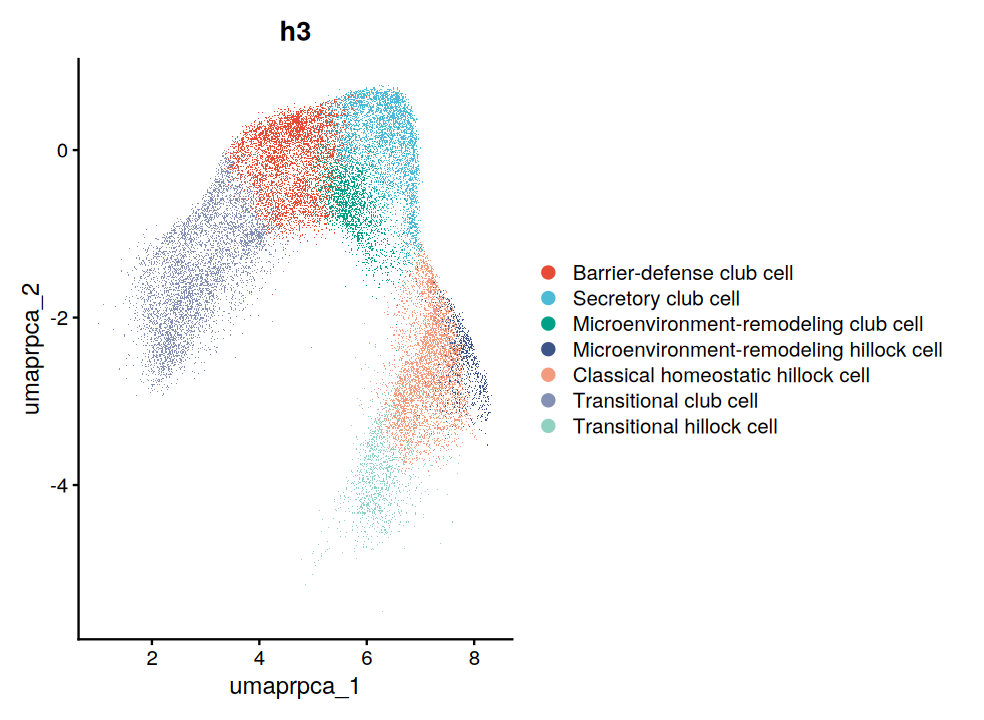

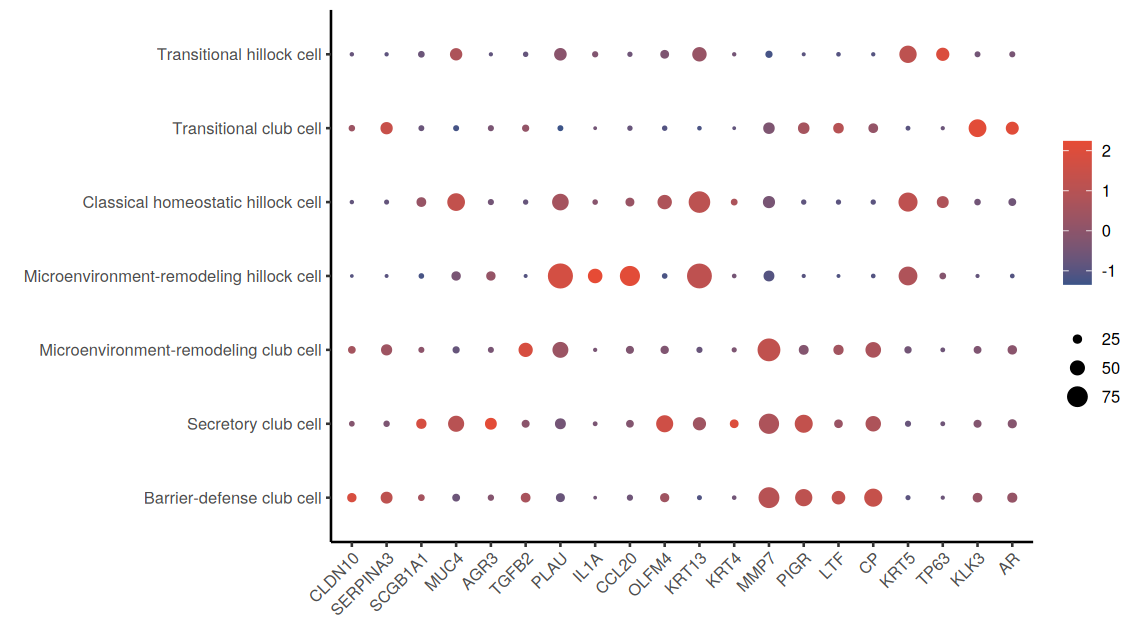

In [10]:
## B UMAP + marker
options(repr.plot.width = 8.2, repr.plot.height = 6)
p_umap <- DimPlot(seu, reduction = "umap.rpca", group.by = "h3",
                   raster = TRUE) +
  scale_color_manual(values = cols_h3) 
p_umap

genes <- c("CLDN10", "SERPINA3", "SCGB1A1", "MUC4", "AGR3",
           "TGFB2", "PLAU", "IL1A", "CCL20", "OLFM4",
           "KRT13", "KRT4", "MMP7", "PIGR", "LTF", "CP",
           "KRT5", "TP63", "KLK3", "AR")
genes <- genes[genes %in% rownames(seu)]
options(repr.plot.width = 9.5, repr.plot.height = 5.2)
DotPlot(seu, features = genes, group.by = "h3", dot.scale = 6) +
  scale_color_gradientn(colours = pal_npg("nrc")(6)[c(4, 1)]) +
  th + theme(axis.text.x = element_text(angle = 45, hjust = 1),
             axis.title = element_blank())

In [ ]:
## B2 CytoTRACE2：Club / Hillock 分开；高分→低分即方向
library(CytoTRACE2)

if (!exists("seu")) {
  seu <- qs::qread(file.path(root, "output/11/club_hillock.qs"))
}
seu <- drop_gse_cells(seu)

xlab_wrap <- c(
  "Barrier-defense club cell"                = "Barrier-defense\nclub cell",
  "Secretory club cell"                      = "Secretory\nclub cell",
  "Microenvironment-remodeling club cell"    = "Microenvironment-remodeling\nclub cell",
  "Transitional club cell"                   = "Transitional\nclub cell",
  "Microenvironment-remodeling hillock cell" = "Microenvironment-remodeling\nhillock cell",
  "Classical homeostatic hillock cell"       = "Classical homeostatic\nhillock cell",
  "Transitional hillock cell"                = "Transitional\nhillock cell"
)

h3_ct <- as.character(seu[["h3"]][, 1])

lin <- list(
  Club = c("Transitional club cell",
           "Barrier-defense club cell",
           "Secretory club cell",
           "Microenvironment-remodeling club cell"),
  Hillock = c("Transitional hillock cell",
              "Microenvironment-remodeling hillock cell",
              "Classical homeostatic hillock cell")
)

ct_f <- file.path(root, "output/11/cytotrace_club_hillock.qs")
if (file.exists(ct_f)) {
  ct <- qs::qread(ct_f)
} else {
  ct <- lapply(lin, function(clus) {
    cytotrace2(seu[, h3_ct %in% clus],
               is_seurat = TRUE, slot_type = "counts",
               species = "human", seed = 121)
  })
  qs::qsave(ct, ct_f)
}
ct <- lapply(ct, drop_gse_cells)

p_dim <- lapply(names(ct), function(nm) {
  DimPlot(ct[[nm]], reduction = "umap.rpca", group.by = "h3",
          raster = TRUE) +
    scale_color_manual(values = cols_h3)
})
p_fe <- lapply(names(ct), function(nm) {
  FeaturePlot(ct[[nm]], features = "CytoTRACE2_Score",
              reduction = "umap.rpca", raster = TRUE,
              min.cutoff = "q5", max.cutoff = "q95", order = TRUE) +
    scale_color_gradientn(colours = pal_npg("nrc")(6)[c(4, 6, 1)],
                          name = "CytoTRACE2")
})

h3_ord <- c(
  "Transitional club cell", "Barrier-defense club cell",
  "Secretory club cell", "Microenvironment-remodeling club cell",
  "Transitional hillock cell", "Microenvironment-remodeling hillock cell",
  "Classical homeostatic hillock cell"
)

df_ct <- do.call(rbind, lapply(names(ct), function(nm) {
  obj <- ct[[nm]]
  data.frame(
    h3_ct = as.character(obj[["h3"]][, 1]),
    score = obj$CytoTRACE2_Score,
    lineage = nm,
    stringsAsFactors = FALSE
  )
}))
df_ct$h3_ct <- factor(df_ct$h3_ct, levels = h3_ord)

ylim_lin <- c(Club = 0.3, Hillock = 0.6)

vln_one <- function(lin, x_l = 0.08, ylab = "CytoTRACE2 score") {
  d <- df_ct[df_ct$lineage == lin, , drop = FALSE]
  d$h3_ct <- droplevels(d$h3_ct)
  ymax <- unname(ylim_lin[lin])
  if (is.na(ymax)) ymax <- 0.3
  med <- aggregate(score ~ h3_ct, d, median)
  med$y <- ymax
  ggplot(d, aes(h3_ct, score, fill = h3_ct)) +
    geom_violin(scale = "width", trim = TRUE, color = NA, alpha = .9, width = .9) +
    geom_boxplot(width = .14, outlier.shape = NA, fill = "white",
                 color = "grey25", linewidth = .35) +
    geom_text(data = med, aes(h3_ct, y, label = sprintf("%.3f", score)),
              vjust = 1.25, size = 3.5, color = "grey15", inherit.aes = FALSE) +
    scale_fill_manual(values = cols_h3) +
    scale_x_discrete(labels = xlab_wrap,
                     expand = expansion(mult = c(x_l, 0.08))) +
    coord_cartesian(ylim = c(0, ymax)) +
    ggtitle(lin) +
    th + theme(axis.text.x = element_text(lineheight = 1.05),
               legend.position = "none",
               plot.title = element_text(face = "bold", hjust = 0.5),
               panel.grid = element_blank()) +
    labs(x = NULL, y = ylab)
}

options(repr.plot.width = 12.5, repr.plot.height = 13.6)
(p_dim[[1]] | p_fe[[1]]) / (p_dim[[2]] | p_fe[[2]]) /
  (vln_one(names(ct)[1]) | vln_one(names(ct)[2], x_l = 0.28, ylab = NULL)) +
  plot_layout(widths = c(1.45, 1), heights = c(1, 1, 0.95))

cytotrace2: Started loading data



: 

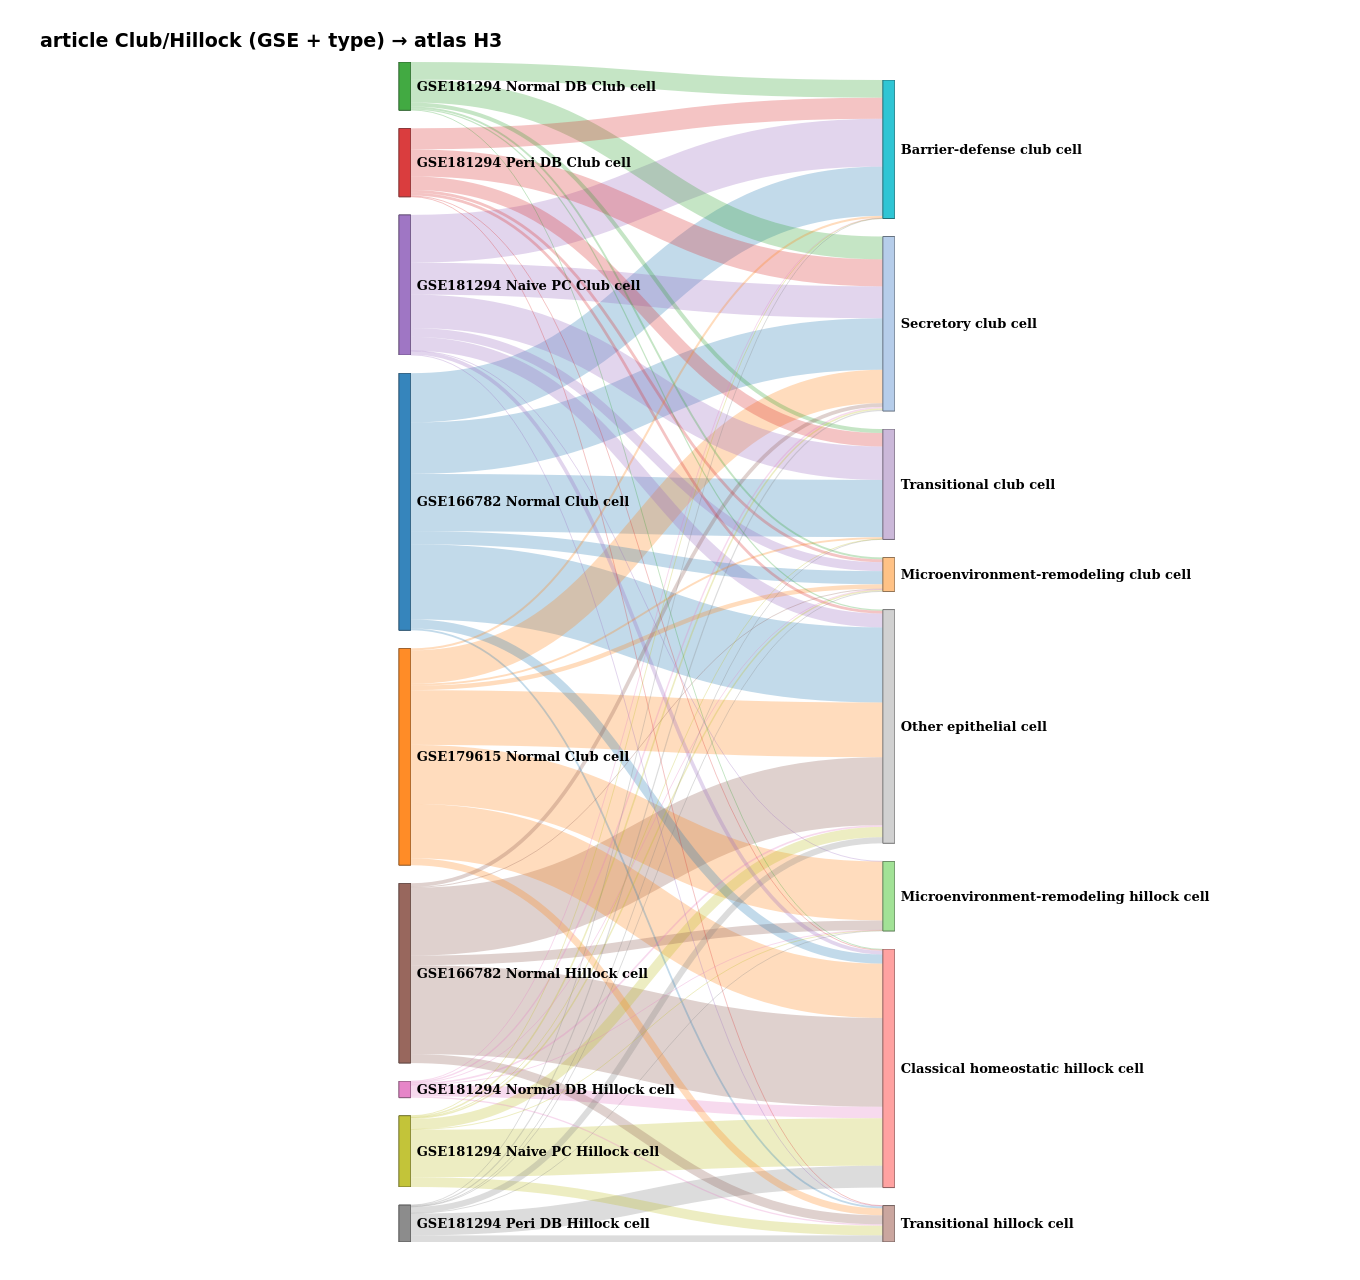

In [57]:
## C
library(networkD3)
library(htmlwidgets)
library(htmltools)
Sys.setenv(OPENSSL_CONF = "/dev/null")
Sys.setenv(PATH = paste("/home/data/tanglei01/bin", Sys.getenv("PATH"), sep = ":"))

gse_club <- c("GSE166782", "GSE179615", "GSE181294")
other_lab <- "Other epithelial cell"
type_lab_sk <- type_lab
type_lab_sk["Normal_DB"] <- "Normal DB"
type_lab_sk["Per_PC_DB"] <- "Peri DB"
lv_left <- unlist(lapply(c("Club cell", "Hillock cell"), function(ct) {
  unlist(lapply(type_lv, function(t) {
    paste(gse_club, unname(type_lab_sk[t]), ct)
  }))
}))

cellmeta.sankey <- epi@meta.data %>%
  dplyr::filter(GSE.ID %in% gse_club,
                celltype_article_H2 %in% c("Club cell", "Hillock cell")) %>%
  dplyr::mutate(
    type_s = recode(as.character(type), !!!as.list(type_lab_sk)),
    left = factor(paste(GSE.ID, type_s, celltype_article_H2), levels = lv_left),
    celltype_manual_H3 = ifelse(
      as.character(celltype_manual_H3) %in% names(h3_map),
      unname(h3_map[as.character(celltype_manual_H3)]),
      other_lab
    )
  )

data.sankey <- cellmeta.sankey %>%
  dplyr::group_by(left, celltype_manual_H3, .drop = TRUE) %>%
  dplyr::summarise(value = dplyr::n(), .groups = "drop") %>%
  dplyr::transmute(
    source = paste0("L0_", left),
    target = paste0("L1_", celltype_manual_H3),
    value
  )

left_used <- as.character(unique(na.omit(cellmeta.sankey$left)))
left_used <- left_used[order(match(left_used, lv_left))]
right_used <- c(h3_lv, other_lab)
right_used <- right_used[right_used %in% sub("^L1_", "", data.sankey$target)]

nodes <- data.frame(
  name = c(paste0("L0_", left_used), paste0("L1_", right_used)),
  stringsAsFactors = FALSE
)
n_node <- nrow(nodes)
nodes$group <- paste0("g", seq_len(n_node) - 1)

if (n_node <= 20) {
  pal <- substr(ggsci::pal_d3("category20")(20)[seq_len(n_node)], 1, 7)
} else {
  pal <- substr(grDevices::colorRampPalette(ggsci::pal_igv("default")(51))(n_node), 1, 7)
}
pal[grepl(other_lab, nodes$name, fixed = TRUE)] <- "#CCCCCC"
nodes$color <- pal

links <- as.data.frame(data.sankey, stringsAsFactors = FALSE)
links$IDsource <- match(links$source, nodes$name) - 1
links$IDtarget <- match(links$target, nodes$name) - 1

ColourScale <- sprintf(
  "d3.scaleOrdinal().domain([%s]).range([%s])",
  paste0('"', nodes$group, '"', collapse = ","),
  paste0('"', nodes$color, '"', collapse = ",")
)

n.side <- max(length(left_used), length(right_used))
plot.h <- max(1200, n.side * 72)
plot.w <- 1300

g <- sankeyNetwork(
  Links = links, Nodes = nodes,
  Source = "IDsource", Target = "IDtarget", Value = "value",
  NodeID = "name", NodeGroup = "group", colourScale = ColourScale,
  sinksRight = FALSE,
  fontSize = 13, nodeWidth = 12, nodePadding = 18,
  margin = list(left = 20, right = 300, top = 10, bottom = 10),
  height = plot.h, width = plot.w
)

js_col <- paste0("{", paste0('"', nodes$group, '":"', nodes$color, '"', collapse = ","), "}")
g <- htmlwidgets::onRender(g, paste0('
  function(el, x) {
    var col = ', js_col, ';
    d3.select(el).selectAll(".node rect")
      .style("fill", function(d) { return col[d.group] || "#888888"; });
    d3.select(el).selectAll(".link")
      .style("stroke", function(d) { return col[d.source.group] || "#888888"; })
      .style("stroke-opacity", 0.28);
    d3.select(el).selectAll(".node text")
      .text(function(d) { return d.name.replace(/^L[0-9]+_/, ""); })
      .style("font-weight", "bold");
  }
'))

g <- htmlwidgets::prependContent(
  g,
  htmltools::tags$h3(
    "article Club/Hillock (GSE + type) → atlas H3",
    style = "text-align:left;font-family:sans-serif;margin-bottom:0;padding-left:30px;"
  )
)

output_dir <- file.path(root, "output/11")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
html.out <- file.path(output_dir, "sankey_article_club_hillock_to_H3.html")
pdf.out  <- file.path(output_dir, "sankey_article_club_hillock_to_H3.pdf")
png.out  <- file.path(output_dir, "sankey_article_club_hillock_to_H3.png")

saveWidget(g, file = html.out, selfcontained = FALSE)
webshot::webshot(url = html.out, file = c(pdf.out, png.out),
                 vwidth = plot.w + 60, vheight = plot.h + 80, delay = 2)
IRdisplay::display_png(file = png.out)

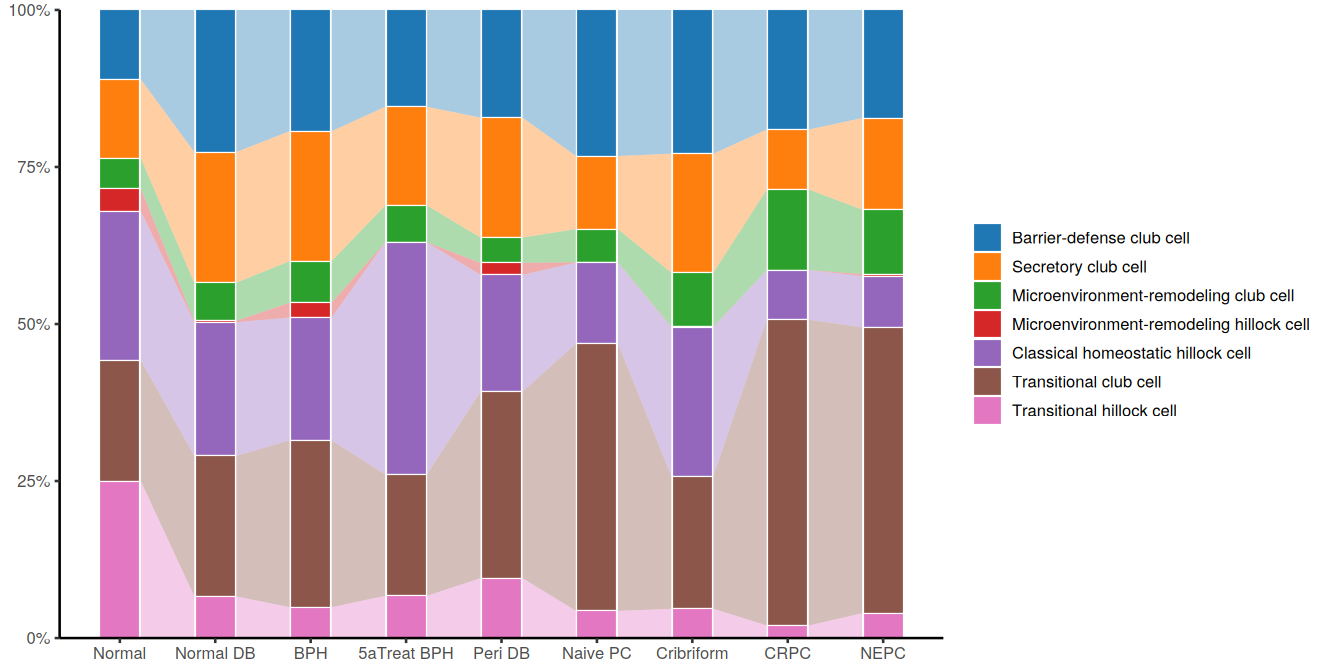

In [59]:
## D type 堆叠（样本比例再平均）+ 柱间连线
type_use <- c("Normal", "Normal_DB", "Naive_BPH", "5aTreat_BPH", "Per_PC_DB",
              "Naive_PC", "Cribriform_PC", "CRPC_A", "NEPC")
type_lab_sk <- c(Normal = "Normal", Normal_DB = "Normal DB",
                 Naive_BPH = "BPH", `5aTreat_BPH` = "5aTreat BPH",
                 Per_PC_DB = "Peri DB", Naive_PC = "Naive PC",
                 Cribriform_PC = "Cribriform", CRPC_A = "CRPC", NEPC = "NEPC")
cols_use <- setNames(substr(pal_d3("category20")(length(h3_lv)), 1, 7), h3_lv)

md <- seu@meta.data %>% dplyr::filter(type %in% type_use)
samp_type <- dplyr::distinct(md, sample.ID, type)
d <- md %>%
  dplyr::count(sample.ID, h3, name = "n") %>%
  tidyr::complete(sample.ID, h3, fill = list(n = 0)) %>%
  dplyr::group_by(sample.ID) %>% dplyr::mutate(frac = n / sum(n)) %>% dplyr::ungroup() %>%
  dplyr::left_join(samp_type, by = "sample.ID") %>%
  dplyr::group_by(type, h3) %>% dplyr::summarise(frac = mean(frac), .groups = "drop")
d$h3 <- factor(d$h3, levels = h3_lv)
d$type <- factor(d$type, levels = type_use)
d <- tidyr::complete(d, type, h3, fill = list(frac = 0))
d$h3 <- factor(d$h3, levels = h3_lv)
d$type <- factor(d$type, levels = type_use)
d <- d %>% dplyr::group_by(type) %>% dplyr::arrange(h3, .by_group = TRUE) %>%
  dplyr::mutate(ymax = 1 - lag(cumsum(frac), default = 0),
                ymin = ymax - frac,
                x = as.numeric(type))

rib <- do.call(rbind, lapply(seq_len(length(type_use) - 1), function(i) {
  a <- subset(d, x == i); b <- subset(d, x == i + 1)
  do.call(rbind, lapply(h3_lv, function(ct) {
    aa <- a[a$h3 == ct, ]; bb <- b[b$h3 == ct, ]
    data.frame(id = paste(i, ct), h3 = ct,
               x = c(i + .22, i + 1 - .22, i + 1 - .22, i + .22),
               y = c(aa$ymax, bb$ymax, bb$ymin, aa$ymin))
  }))
}))

options(repr.plot.width = 11.2, repr.plot.height = 5.6)
ggplot() +
  geom_polygon(data = rib, aes(x, y, group = id, fill = h3),
               alpha = .38, color = NA) +
  geom_rect(data = d, aes(xmin = x - .21, xmax = x + .21,
                          ymin = ymin, ymax = ymax, fill = h3),
            color = "white", linewidth = .25) +
  scale_fill_manual(values = cols_use) +
  scale_x_continuous(breaks = seq_along(type_use), labels = unname(type_lab_sk[type_use])) +
  scale_y_continuous(expand = c(0, 0), labels = percent_format()) +
  th + labs(x = NULL, y = NULL)

Warning message in geom_errorbar(aes(xmin = logFC - xerr, xmax = logFC + xerr), :
“Ignoring unknown parameters: `height`”
Warning message in geom_errorbar(aes(xmin = logFC - xerr, xmax = logFC + xerr), :
“Ignoring unknown parameters: `height`”
Warning message in geom_errorbar(aes(xmin = logFC - xerr, xmax = logFC + xerr), :
“Ignoring unknown parameters: `height`”


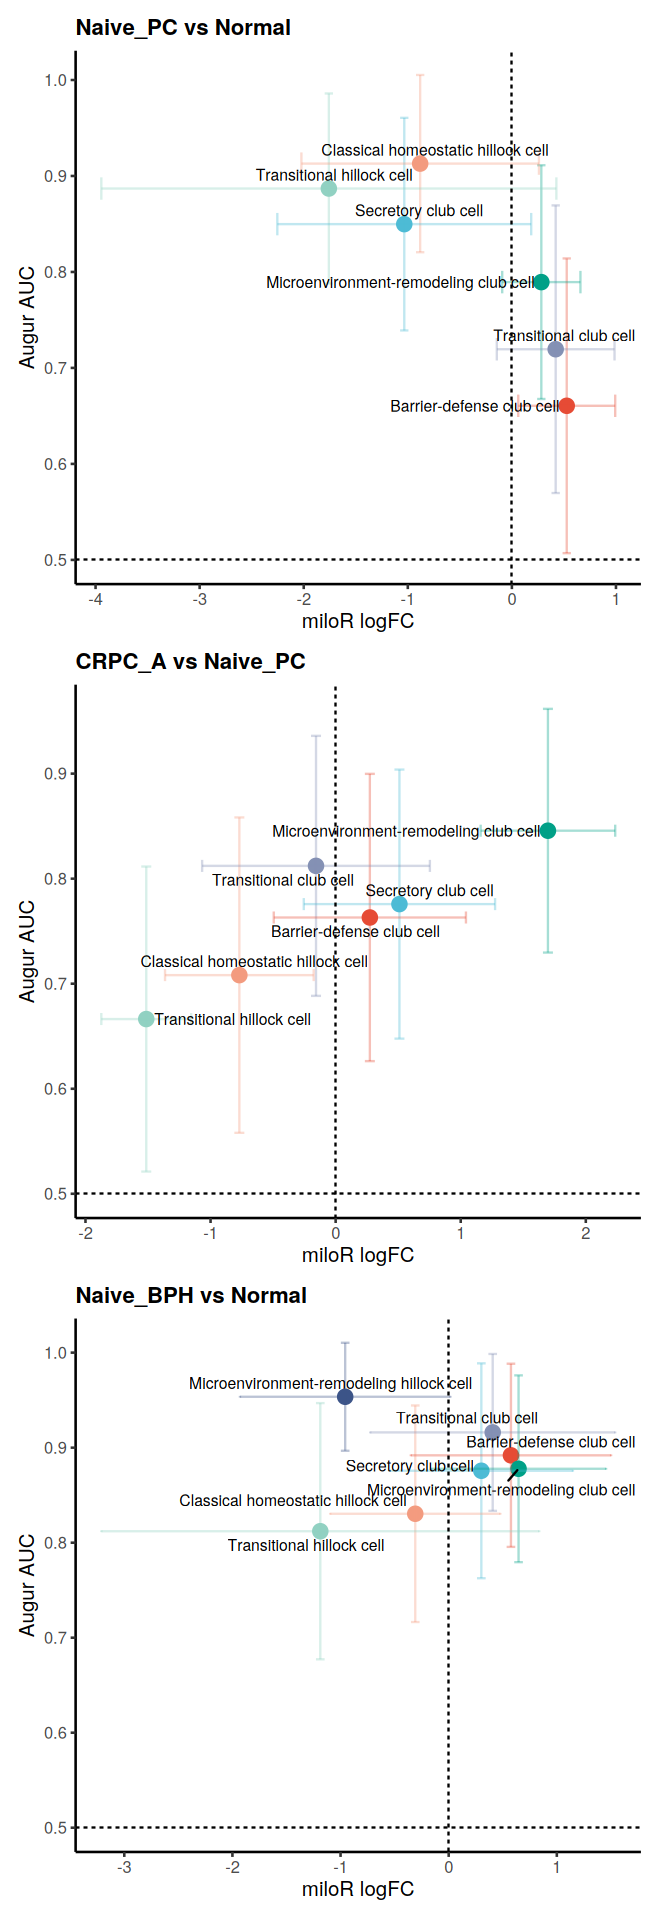

In [65]:
## E miloR + Augur：三对一对一对照，再画合并图
library(miloR)
library(SingleCellExperiment)
library(Augur)
library(ggrepel)

if (!exists("seu")) {
  seu <- qs::qread(file.path(root, "output/11/club_hillock.qs"))
}
seu <- drop_gse_cells(seu)
if (!length(VariableFeatures(seu))) {
  seu <- FindVariableFeatures(seu, nfeatures = 2000, verbose = FALSE)
}

contrasts <- list(
  NaivePC_vs_Normal = c(ref = "Normal", query = "Naive_PC"),
  CRPC_vs_NaivePC   = c(ref = "Naive_PC", query = "CRPC_A"),
  BPH_vs_Normal     = c(ref = "Normal", query = "Naive_BPH")
)
genes_milo <- VariableFeatures(seu)[seq_len(min(500, length(VariableFeatures(seu))))]

run_one <- function(ref, query) {
  keep <- as.character(seu[["type"]][, 1]) %in% c(ref, query)
  seu_c <- seu[, keep]
  sce <- SingleCellExperiment(
    assays = list(counts = GetAssayData(seu_c, assay = "RNA", layer = "counts")[genes_milo, ]),
    reducedDims = SimpleList(
      RPCA = Embeddings(seu_c, "rpca"),
      UMAP = Embeddings(seu_c, "umap.rpca")
    )
  )
  milo <- Milo(sce)
  milo <- buildGraph(milo, k = 30, d = 30, reduced.dim = "RPCA")
  milo <- makeNhoods(milo, prop = 0.1, k = 30, d = 30, refined = TRUE, reduced_dims = "RPCA")
  milo <- calcNhoodDistance(milo, d = 30, reduced.dim = "RPCA")
  group_vec <- factor(ifelse(as.character(seu_c[["type"]][, 1]) == query, "Query", "Ref"),
                      levels = c("Ref", "Query"))
  meta <- data.frame(
    sample = paste0(as.character(seu_c[["sample.ID"]][, 1]), ".", group_vec),
    group = group_vec,
    celltype = as.character(seu_c[["h3"]][, 1]),
    row.names = colnames(seu_c)
  )
  colData(milo) <- DataFrame(meta)
  milo <- countCells(milo, meta.data = as.data.frame(colData(milo)), sample = "sample")
  des <- as.data.frame(colData(milo)) %>%
    dplyr::select(sample, group) %>% dplyr::distinct()
  des$group <- factor(des$group, levels = c("Ref", "Query"))
  rownames(des) <- des$sample
  da <- testNhoods(milo, design = ~ group, design.df = des, reduced.dim = "RPCA")
  da <- annotateNhoods(milo, da, coldata_col = "celltype")
  da$celltype <- ifelse(da$celltype_fraction < 0.7, "Mixed", as.character(da$celltype))

  seu_a <- DietSeurat(seu_c, assays = "RNA", counts = TRUE, data = TRUE,
                      scale.data = FALSE, dimreducs = NULL)
  seu_a <- seu_a[intersect(VariableFeatures(seu), rownames(seu_a)), ]
  seu_a$augur_label <- as.character(group_vec)
  aug <- calculate_auc(seu_a, cell_type_col = "h3",
                       label_col = "augur_label", n_threads = 1)
  list(da = da, aug = aug, tit = paste0(query, " vs ", ref))
}

res <- list()
for (nm in names(contrasts)) {
  res[[nm]] <- run_one(contrasts[[nm]]["ref"], contrasts[[nm]]["query"])
  qs::qsave(res, file.path(root, "output/11/milo_augur_3contrasts.qs"))
}

re_comb <- function(x) {
  d1 <- x$da %>%
    dplyr::group_by(celltype) %>%
    dplyr::summarise(xerr = stats::sd(logFC), logFC = mean(logFC), .groups = "drop")
  names(d1)[1] <- "cell_type"
  d2 <- subset(x$aug$results, metric == "roc_auc") %>%
    dplyr::group_by(cell_type) %>%
    dplyr::summarise(yerr = stats::sd(estimate), auc = mean(estimate), .groups = "drop")
  dp <- dplyr::inner_join(d1, d2, by = "cell_type")
  dp$xerr[is.na(dp$xerr)] <- 0
  dp$yerr[is.na(dp$yerr)] <- 0
  ggplot(dp, aes(logFC, auc, color = cell_type, label = cell_type)) +
    geom_point(size = 3.6) +
    geom_errorbar(aes(ymin = auc - yerr, ymax = auc + yerr), width = .08, alpha = .35) +
    geom_errorbar(aes(xmin = logFC - xerr, xmax = logFC + xerr),
                  height = .02, alpha = .35, orientation = "y") +
    geom_hline(yintercept = .5, linetype = "dashed") +
    geom_vline(xintercept = 0, linetype = "dashed") +
    ggrepel::geom_text_repel(show.legend = FALSE, color = "black", size = 3.2) +
    scale_color_manual(values = cols_h3) +
    th + theme(legend.position = "none") +
    labs(x = "miloR logFC", y = "Augur AUC", title = x$tit)
}

for (nm in names(res)) res[[nm]]$p_comb <- re_comb(res[[nm]])

options(repr.plot.width = 5.5, repr.plot.height = 16)
res$NaivePC_vs_Normal$p_comb /
  res$CRPC_vs_NaivePC$p_comb /
  res$BPH_vs_Normal$p_comb

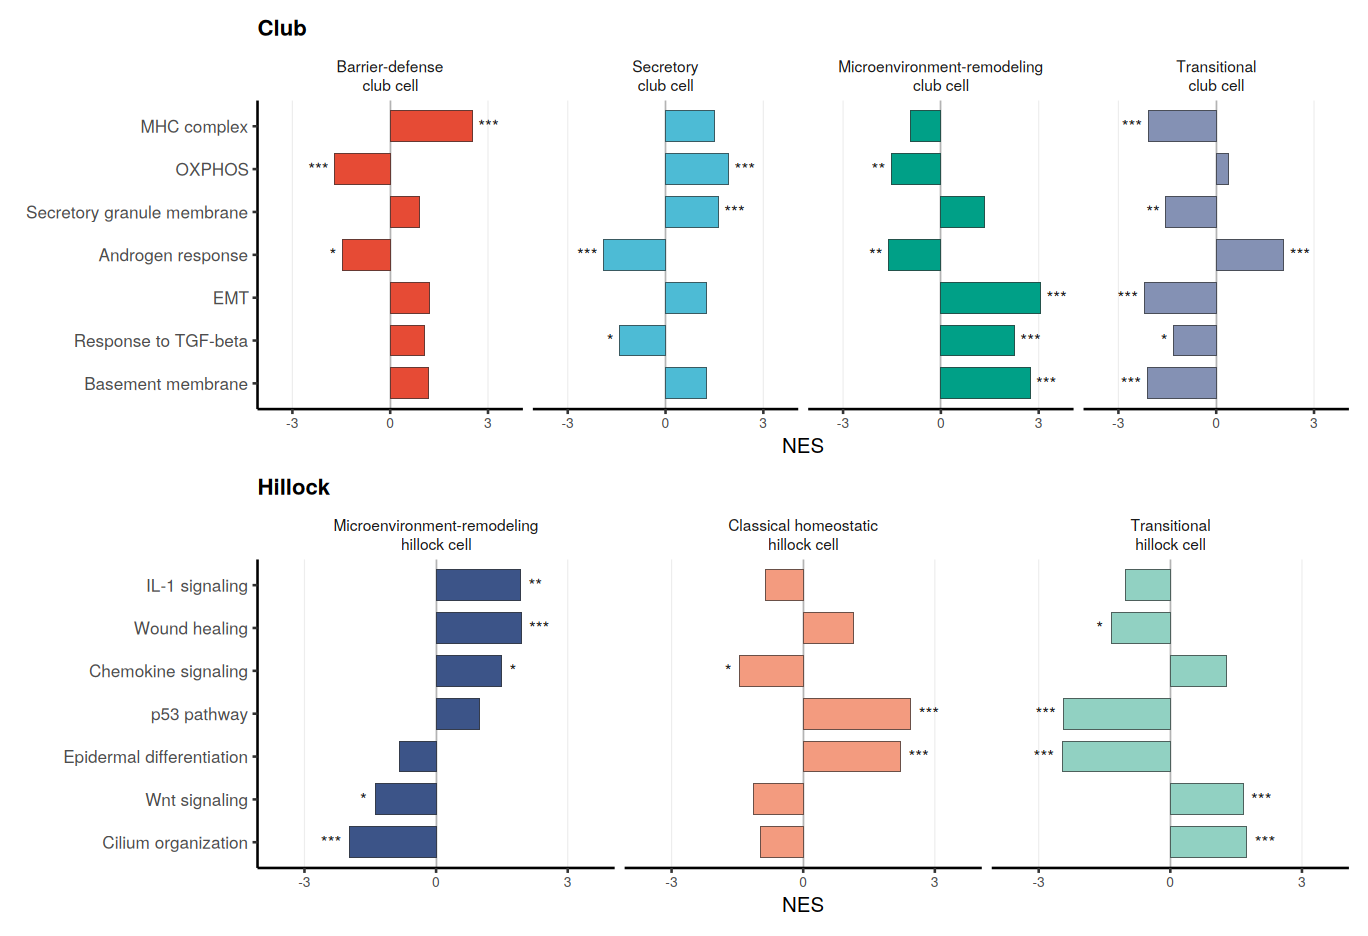

In [87]:
## F 条形图。条长 = NES，颜色 = 亚型，* / ** / *** = p。
## 缺 output/11/gsea/de_fgsea_*.csv 时按 subtype vs 同谱系 rest 重算。
gsea_dir <- file.path(root, "output/11/gsea")
dir.create(gsea_dir, recursive = TRUE, showWarnings = FALSE)
tag_h3 <- c(
  Barrier   = "Barrier-defense club cell",
  Secretory = "Secretory club cell",
  RemodelC  = "Microenvironment-remodeling club cell",
  TransC    = "Transitional club cell",
  RemodelH  = "Microenvironment-remodeling hillock cell",
  Homeo     = "Classical homeostatic hillock cell",
  TransH    = "Transitional hillock cell"
)
pw_club <- c(
  GOCC_MHC_PROTEIN_COMPLEX                         = "MHC complex",
  HALLMARK_OXIDATIVE_PHOSPHORYLATION               = "OXPHOS",
  GOCC_SECRETORY_GRANULE_MEMBRANE                  = "Secretory granule membrane",
  HALLMARK_ANDROGEN_RESPONSE                       = "Androgen response",
  HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION       = "EMT",
  GOBP_RESPONSE_TO_TRANSFORMING_GROWTH_FACTOR_BETA = "Response to TGF-beta",
  GOCC_BASEMENT_MEMBRANE                           = "Basement membrane"
)
pw_hill <- c(
  HALLMARK_INFLAMMATORY_RESPONSE                = "Inflammatory response",
  GOBP_WOUND_HEALING                            = "Wound healing",
  KEGG_CHEMOKINE_SIGNALING_PATHWAY              = "Chemokine signaling",
  HALLMARK_P53_PATHWAY                          = "p53 pathway",
  GOBP_EPIDERMAL_CELL_DIFFERENTIATION           = "Epidermal differentiation",
  GOBP_REGULATION_OF_WNT_SIGNALING_PATHWAY      = "Wnt signaling",
  GOBP_CILIUM_ORGANIZATION                      = "Cilium organization"
)
xlab_wrap <- c(
  "Barrier-defense club cell"                = "Barrier-defense\nclub cell",
  "Secretory club cell"                      = "Secretory\nclub cell",
  "Microenvironment-remodeling club cell"    = "Microenvironment-remodeling\nclub cell",
  "Transitional club cell"                   = "Transitional\nclub cell",
  "Microenvironment-remodeling hillock cell" = "Microenvironment-remodeling\nhillock cell",
  "Classical homeostatic hillock cell"       = "Classical homeostatic\nhillock cell",
  "Transitional hillock cell"                = "Transitional\nhillock cell"
)
club_h3 <- unname(tag_h3[c("Barrier", "Secretory", "RemodelC", "TransC")])
hill_h3 <- unname(tag_h3[c("RemodelH", "Homeo", "TransH")])
gsea_f <- function(tag) file.path(gsea_dir, paste0("de_fgsea_", tag, ".csv"))
need <- names(tag_h3)
miss <- need[!file.exists(vapply(need, gsea_f, ""))]

if (length(miss)) {
  message("GSEA 缺文件，重算：", paste(miss, collapse = ", "))
  suppressPackageStartupMessages({
    library(Matrix); library(limma); library(edgeR); library(fgsea); library(BiocParallel)
    register(SerialParam())
  })
  h3 <- as.character(seu[["h3"]][, 1])
  sid <- as.character(seu[["sample.ID"]][, 1])
  counts <- GetAssayData(seu, assay = "RNA", layer = "counts")
  counts <- counts[Matrix::rowSums(counts > 0) >= 50, ]
  pb_one <- function(cells) {
    if (length(cells) < 8) return(NULL)
    as.numeric(Matrix::rowSums(counts[, cells, drop = FALSE]))
  }
  units <- list()
  for (s in unique(sid)) for (ct in unname(tag_h3)) {
    v <- pb_one(which(sid == s & h3 == ct))
    if (is.null(v)) next
    units[[length(units) + 1]] <- list(h3 = ct, y = v)
  }
  Y <- do.call(cbind, lapply(units, `[[`, "y"))
  rownames(Y) <- rownames(counts)
  meta <- data.frame(h3 = vapply(units, `[[`, "", "h3"), stringsAsFactors = FALSE)
  read_gmt <- function(f) {
    sets <- list(); con <- file(f, open = "r")
    while (length(ln <- readLines(con, n = 1))) {
      sp <- strsplit(ln, "\t")[[1]]; sets[[sp[1]]] <- unique(sp[-(1:2)])
    }
    close(con); sets
  }
  gmt_all <- c(
    read_gmt(file.path(root, "vis/data/gsea/h.all.v2022.1.Hs.symbols.gmt")),
    read_gmt(file.path(root, "vis/data/gsea/c2.cp.kegg.v2022.1.Hs.symbols.gmt")),
    read_gmt(file.path(root, "vis/data/gsea/c5.go.bp.v2024.1.Hs.symbols.gmt")),
    read_gmt(file.path(root, "vis/data/gsea/c5.go.cc.v2025.1.Hs.symbols.gmt"))
  )
  run1 <- function(target_h3, lineage, tag) {
    ok <- meta$h3 %in% lineage
    y <- Y[, ok, drop = FALSE]
    md <- meta[ok, , drop = FALSE]
    grp <- factor(ifelse(md$h3 == target_h3, "target", "rest"),
                  levels = c("rest", "target"))
    dge <- DGEList(y); keep <- filterByExpr(dge, group = grp)
    dge <- calcNormFactors(dge[keep, , keep.lib.sizes = FALSE])
    design <- model.matrix(~ grp)
    tt <- topTable(eBayes(lmFit(voom(dge, design, plot = FALSE), design)),
                   coef = "grptarget", number = Inf, sort.by = "P")
    stats <- setNames(tt$t, rownames(tt)); stats <- stats[is.finite(stats)]
    set_use <- lapply(gmt_all, function(g) intersect(g, names(stats)))
    set_use <- set_use[lengths(set_use) >= 10 & lengths(set_use) <= 250]
    fg <- fgseaMultilevel(pathways = set_use, stats = stats, minSize = 10, maxSize = 250,
                          nproc = 1, BPPARAM = SerialParam())
    fg$leadingEdge <- vapply(fg$leadingEdge, function(x) paste(x, collapse = ";"), "")
    fg <- as.data.frame(fg)
    write.csv(fg, gsea_f(tag), row.names = FALSE)
  }
  lin_of <- function(h3n) if (h3n %in% club_h3) club_h3 else hill_h3
  for (tag in miss) run1(unname(tag_h3[[tag]]), lin_of(unname(tag_h3[[tag]])), tag)
}

allg <- dplyr::bind_rows(lapply(need, function(tag) {
  d <- read.csv(gsea_f(tag), stringsAsFactors = FALSE)
  d$h3 <- tag_h3[[tag]]
  d
}))
prep_gsea <- function(cts, pw_keep) {
  dd <- allg[as.character(allg$h3) %in% cts & allg$pathway %in% names(pw_keep),
             c("h3", "pathway", "pval", "NES")]
  dd$pw <- factor(unname(pw_keep[dd$pathway]), levels = rev(unname(pw_keep)))
  dd$h3 <- factor(dd$h3, levels = intersect(h3_lv, cts))
  dd$star <- ifelse(dd$pval < 0.001, "***",
             ifelse(dd$pval < 0.01, "**",
             ifelse(dd$pval < 0.05, "*", "")))
  dd
}
plot_gsea_bar <- function(dd, title) {
  ggplot(dd, aes(NES, pw, fill = h3)) +
    geom_vline(xintercept = 0, colour = "grey70", linewidth = 0.35) +
    geom_col(width = 0.72, color = "grey20", linewidth = 0.15) +
    geom_text(aes(label = star,
                  x = NES + ifelse(NES >= 0, 0.18, -0.18),
                  hjust = ifelse(NES >= 0, 0, 1)),
              size = 3.6, colour = "grey10") +
    scale_fill_manual(values = cols_h3) +
    scale_x_continuous(limits = c(-3.7, 3.7), breaks = c(-3, 0, 3)) +
    facet_wrap(~ h3, nrow = 1, labeller = labeller(h3 = xlab_wrap)) +
    th +
    theme(strip.background = element_blank(),
          strip.text = element_text(size = 9, lineheight = 1.05),
          axis.text.y = element_text(size = 10),
          axis.text.x = element_text(size = 8),
          panel.grid.major.x = element_line(colour = "grey93", linewidth = 0.25),
          legend.position = "none") +
    labs(x = "NES", y = NULL, title = title)
}

options(repr.plot.width = 11.4, repr.plot.height = 7.8)
plot_gsea_bar(prep_gsea(club_h3, pw_club), "Club") /
  plot_gsea_bar(prep_gsea(hill_h3, pw_hill), "Hillock")